In [1]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
os.getcwd()

'/scale/user/mtannaou/alternance'

In [328]:
i_folder = 1

In [329]:
import src.IR_to_SAR.data_preparation.data_preprocessing as dataprep
from src.IR_to_SAR.data_preparation.distribution_data_visualisation import plot_sar,plot_ir,plot_aam
from src.IR_to_SAR.ML_IR_SAR.model import create_model

from importlib import reload
reload(dataprep)
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt;import xarray as xr;import pickle as pkl;import os;import torch
from src.IR_to_SAR.data_preparation.data_preprocessing import create_moment_sar,annular_normalization,annular_denormalization,moment_to_sar,z_score
folder_result = f"/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/combined_loss/train_ir_sar_{i_folder}"

In [330]:
device = "cuda"  #"cuda" if torch.cuda.is_available() else "cpu"
model = create_model(
    image_size=128,
    in_channels=1,
    out_channels=1,
    block_out_channels=(16, 32, 16),   # SMALL UNET
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
)

model = model.to(device)
ckpt_path = os.path.join(folder_result,"best_regression_model.pt")

ckpt = torch.load(ckpt_path, map_location=device)

# le state_dict est dans la clé "model"
state_dict = ckpt["model"]

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("✅ Loaded with strict=False")
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
model.eval()

✅ Loaded with strict=False
Missing keys: 0
Unexpected keys: 0


UNet2DModel(
  (conv_in): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=16, out_features=64, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=64, out_features=64, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(16, 16, eps=1e-05, affine=True)
          (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=64, out_features=16, bias=True)
          (norm2): GroupNorm(16, 16, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(16, 16, kernel_

In [331]:
ind = -1

Text(0.5, 1.0, 'SAR recalculed from moment and vmax 39.82 m/s')

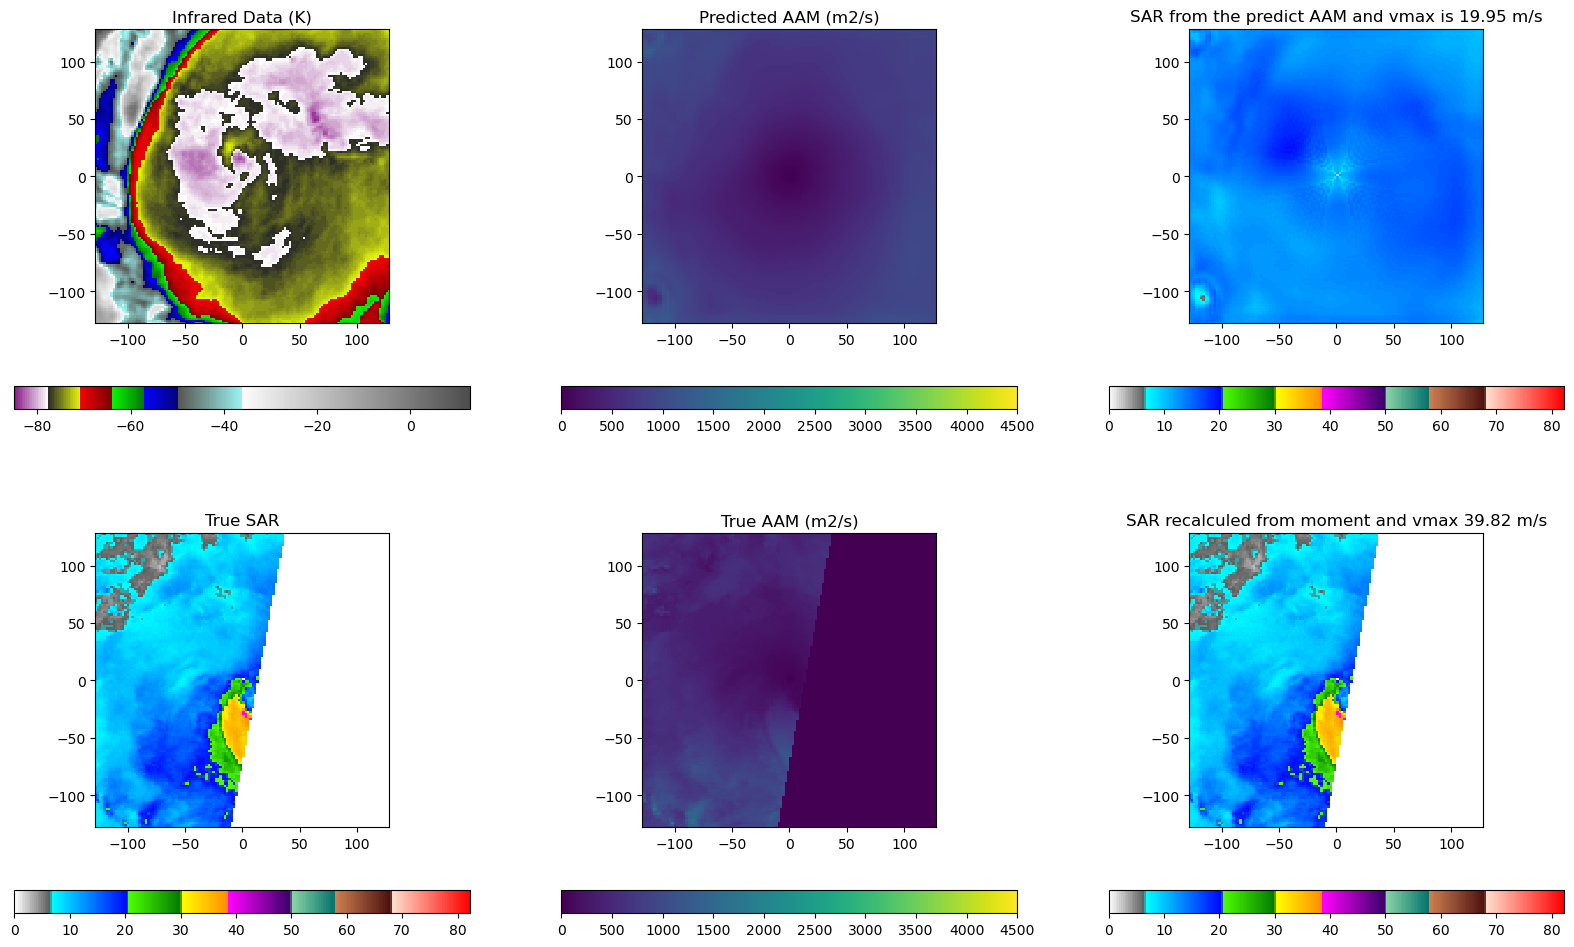

In [332]:
data = pd.read_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/TCVA_matched_with_SARGEO_v3_split_by_year.csv")
ind +=1
with open(os.path.join(folder_result,"predictions_denormalisees/test/predictions_denormalisées.pkl"),"rb") as f:
    data_test = pkl.load(f)["test"]
sar = data_test[1][ind]
irwin = data_test[0][ind]
pred = data_test[2][ind]

    

with open(os.path.join(folder_result,"stats_normalisation/OUTPUT/stats.pkl"),"rb") as f:
    stats = pkl.load(f)
mean_x,std_x = stats["mean_x"],stats["std_x"]
mean_sar, std_sar = stats["mean_sar"], stats["std_sar"]

#aam pred
aam_pred = create_moment_sar(pred.reshape((1,128,128)))
aam_sar = create_moment_sar(sar.reshape((1,128,128)))
sar_from_aam = moment_to_sar(aam_sar)

fig,axs = plt.subplots(2,3,figsize=(20,12))
xlim=128
plot_ir(irwin,x_lim=xlim,ax=axs[0,0],fig=fig) 
axs[0,0].set_title("Infrared Data (K)")
plot_aam(aam_pred.squeeze(),x_lim=xlim,ax=axs[0,1],fig=fig)
axs[0,1].set_title(f"Predicted AAM (m2/s)")
plot_sar(pred.squeeze(),x_lim=xlim,ax=axs[0,2],fig=fig)
axs[0,2].set_title(f"SAR from the predict AAM and vmax is {np.nanmax(pred.squeeze()):.2f} m/s")
plot_sar(sar.squeeze(),x_lim=xlim,ax=axs[1,0],fig=fig)
axs[1,0].set_title("True SAR")
plot_aam(aam_sar.squeeze(),ax=axs[1,1],x_lim=xlim,fig=fig)
axs[1,1].set_title("True AAM (m2/s)")
plot_sar(sar_from_aam.squeeze(),ax=axs[1,2],x_lim=xlim,fig=fig)
axs[1,2].set_title(f"SAR recalculed from moment and vmax {np.nanmax(sar_from_aam.squeeze()):.2f} m/s")


In [333]:
def compute_vmax1d_rmax1d(sar_2d,rayon=71):
        """
        Compute Vmax1D and Rmax1D from a 2D SAR field.
        - Vmax1D: maximum wind speed along radial profile
        - Rmax1D: radius at which Vmax1D occurs
        """
        H, W = sar_2d.shape
        sar_2d = sar_2d[W//2-rayon//2:W//2+rayon//2,H//2-rayon//2:H//2+rayon//2]
        H, W = sar_2d.shape
        cx, cy = W//2, H//2
        Y, X = np.indices((H, W))
        R = np.sqrt((X - cx)**2 + (Y - cy)**2)
        Rmax = int(R.max())
        radii = np.arange(0, Rmax)
        vmax_profile = []
        for R0 in radii:
            mask = (np.abs(R - R0) < 0.5)
            if np.sum(mask) == 0:
                vmax_profile.append(np.nan)
            else:
                vmax_profile.append(np.nanmax(sar_2d[mask]))
        vmax_profile = np.array(vmax_profile)
        # Remove NaNs
        valid = ~np.isnan(vmax_profile)
        vmax_profile = vmax_profile[valid]
        radii = radii[valid]
        vmax1d = np.nanmax(vmax_profile)
        rmax1d = radii[np.nanargmax(vmax_profile)]
        vmax1d_ms = vmax1d
        rmax1d_km = rmax1d * 2
        return vmax1d_ms, rmax1d_km

In [334]:
rayon= 128

In [335]:
vmaxs_sar ,rmaxs_sar = [],[]
analysis_vmaxs,analysis_rmaxs= [], []
predicted_vmaxs, predicted_rmaxs = [],[]
for ir,sar,pred,infos in zip(data_test[0],data_test[1],data_test[2],data_test[4]):
    vmax_sar, rmax_sar = compute_vmax1d_rmax1d(sar,rayon=rayon)
    vmax_pred, rmax_pred = compute_vmax1d_rmax1d(pred,rayon=rayon)
    vmaxs_sar.append(vmax_sar);rmaxs_sar.append(rmax_sar)
    predicted_vmaxs.append(vmax_pred);predicted_rmaxs.append(rmax_pred)
    analysis_vmaxs.append(infos["analysis_vmax"]);analysis_rmaxs.append(infos["analysis_rmax"]/1000)
vmaxs_sar=np.array(vmaxs_sar);rmaxs_sar=np.array(rmaxs_sar);analysis_vmaxs=np.array(analysis_vmaxs);analysis_rmaxs=np.array(analysis_rmaxs)
predicted_rmaxs=np.array(predicted_rmaxs)
predicted_vmaxs=np.array(predicted_vmaxs)

In [336]:
mask=(analysis_rmaxs < 200)
(mask).sum()

np.int64(126)

Text(0.05, 0.95, 'RMSE = 53.98 km\nMAE = 37.40 km')

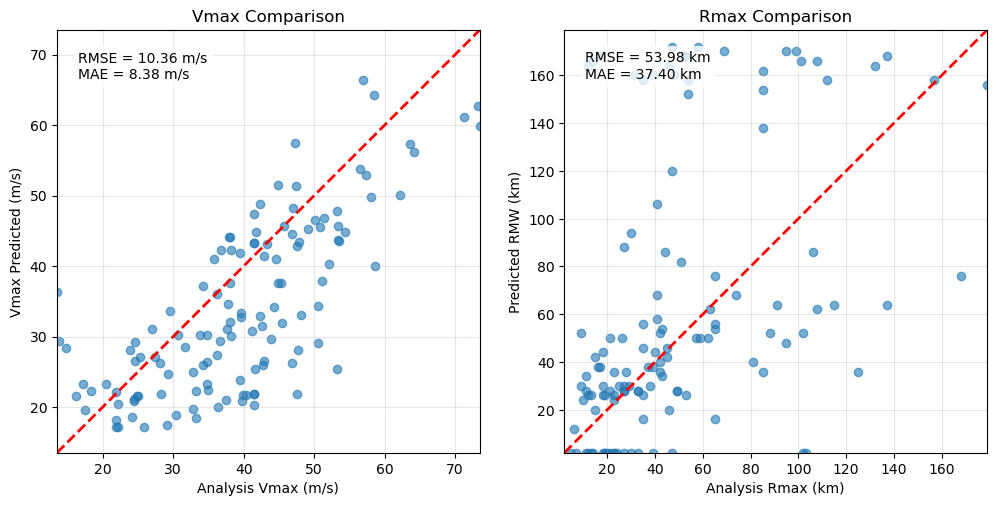

In [337]:
import numpy as np
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,2,figsize=(12,6))
# arrays -> numpy
vmax_pred = np.asarray(predicted_vmaxs)[mask]
vmax_true = np.asarray(analysis_vmaxs)[mask]

# retirer NaN éventuels
valid = np.isfinite(vmax_pred) & np.isfinite(vmax_true)
vmax_pred = vmax_pred[valid]
vmax_true = vmax_true[valid]

# métriques
rmse = np.sqrt(np.mean((vmax_pred - vmax_true) ** 2))
mae = np.mean(np.abs(vmax_pred - vmax_true))

# limites communes
vmin = min(vmax_pred.min(), vmax_true.min())
vmax = max(vmax_pred.max(), vmax_true.max())


axs[0].scatter(vmax_true, vmax_pred, alpha=0.6)

# ligne parfaite
axs[0].plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2)

axs[0].set_xlabel("Analysis Vmax (m/s)")
axs[0].set_ylabel("Vmax Predicted (m/s)")
axs[0].set_title("Vmax Comparison")
axs[0].set_aspect('equal', adjustable='box')

axs[0].set_xlim(vmin, vmax)
axs[0].set_ylim(vmin, vmax)
axs[0].grid(True, alpha=0.3)

# texte métriques
axs[0].text(
    0.05, 0.95,
    f"RMSE = {rmse:.2f} m/s\nMAE = {mae:.2f} m/s",
    transform=axs[0].transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)




# arrays -> numpy
vmax_pred = np.asarray(predicted_rmaxs)[mask]
vmax_true = np.asarray(analysis_rmaxs)[mask]

# retirer NaN éventuels
valid = np.isfinite(vmax_pred) & np.isfinite(vmax_true)
vmax_pred = vmax_pred[valid]
vmax_true = vmax_true[valid]

# métriques
rmse = np.sqrt(np.mean((vmax_pred - vmax_true) ** 2))
mae = np.mean(np.abs(vmax_pred - vmax_true))

# limites communes
vmin = min(vmax_pred.min(), vmax_true.min())
vmax = max(vmax_pred.max(), vmax_true.max())


plt.scatter(vmax_true, vmax_pred, alpha=0.6)

# ligne parfaite
axs[1].plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2)

axs[1].set_xlabel("Analysis Rmax (km)")
axs[1].set_ylabel("Predicted RMW (km)")
axs[1].set_title("Rmax Comparison")

axs[1].set_xlim(vmin, vmax)
axs[1].set_ylim(vmin, vmax)
axs[1].set_aspect('equal', adjustable='box')
axs[1].grid(True, alpha=0.3)

# texte métriques
axs[1].text(
    0.05, 0.95,
    f"RMSE = {rmse:.2f} km\nMAE = {mae:.2f} km",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)





In [338]:
ind=-1
mask = (np.abs(analysis_rmaxs - predicted_rmaxs) < 5)  \
       & (np.abs(analysis_vmaxs - predicted_vmaxs) < 5)
# mask = (analysis_vmaxs < 25 )
mask = (np.abs(np.array(predicted_rmaxs - analysis_rmaxs))<=3) & (np.abs(np.array(predicted_vmaxs - analysis_vmaxs))<=5)
mask = (predicted_rmaxs >= 25) & (predicted_rmaxs <=50)
mask = (np.abs(np.array(predicted_rmaxs - analysis_rmaxs))<=5) &(analysis_vmaxs >50)
mask = (analysis_vmaxs <=20.18)
(mask).sum()

np.int64(7)

Text(0.5, 0.98, 'cyclone_id: al10219 | analysis_rmax : 31.0km | Rmax_SAR : 28km | Predicted Rmax : 160km\n Analysis_vmax : 13.51m/s | Vmax_SAR : 15.73m/s | Predicted_vmax : 36.29m/s')

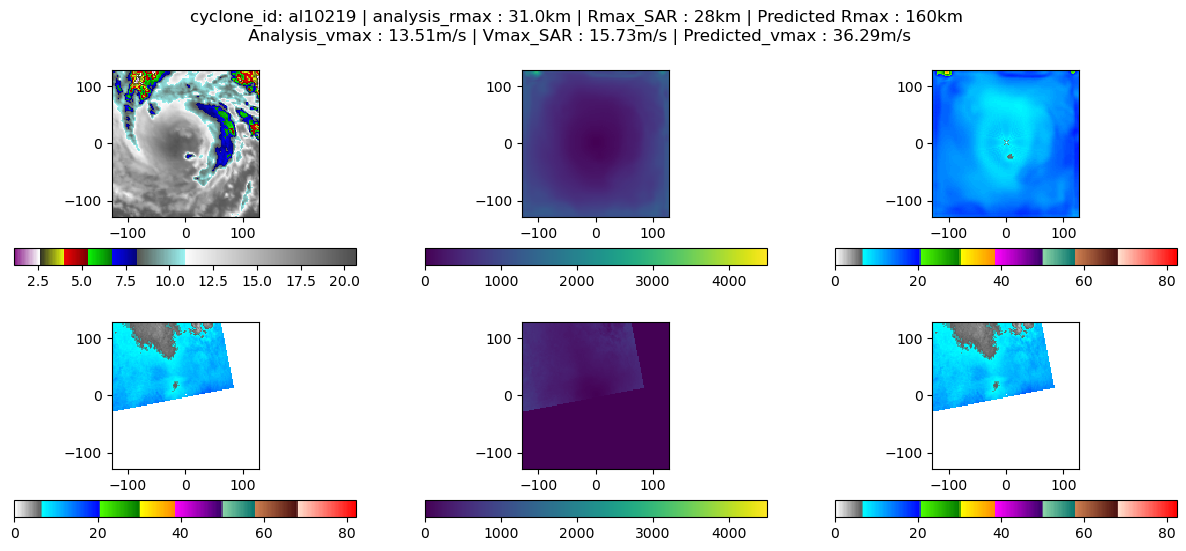

In [343]:
fig,axs = plt.subplots(2,3,figsize=(15,6))
ind+=1
plot_ir(data_test[0][mask][ind],fig=fig,ax=axs[0,0],x_lim=128)
plot_aam(create_moment_sar(data_test[2][mask][ind].reshape((1,128,128))).squeeze(),fig=fig,ax=axs[0,1],x_lim=128)
plot_sar(data_test[2][mask][ind],fig=fig,ax=axs[0,2],x_lim=128)

plot_sar(data_test[1][mask][ind],fig=fig,ax=axs[1,0],x_lim=128)
plot_aam(create_moment_sar(data_test[1][mask][ind].reshape((1,128,128))).squeeze(),fig=fig,ax=axs[1,1],x_lim=128)
plot_sar(moment_to_sar(create_moment_sar(data_test[1][mask][ind].reshape((1,128,128)))).squeeze(),fig=fig,ax=axs[1,2],x_lim=128)
plt.suptitle(f"cyclone_id: al10219 | analysis_rmax : {np.array(data_test[4])[mask][ind]["analysis_rmax"]/1000}km | Rmax_SAR : {rmaxs_sar[mask][ind]}km | Predicted Rmax : {predicted_rmaxs[mask][ind]}km\n Analysis_vmax : {np.array(data_test[4])[mask][ind]["analysis_vmax"]:.2f}m/s | Vmax_SAR : {vmaxs_sar[mask][ind]:.2f}m/s | Predicted_vmax : {predicted_vmaxs[mask][ind]:.2f}m/s")

<function src.IR_to_SAR.data_preparation.data_preprocessing.create_moment_sar(sar)>

In [22]:
vmaxs_ana = analysis_vmaxs[mask]

(array([ 5.,  2., 10., 11., 13.,  6.,  4.,  2.,  1.,  3.]),
 array([22.11886667, 27.25658889, 32.39431111, 37.53203333, 42.66975556,
        47.80747778, 52.9452    , 58.08292222, 63.22064444, 68.35836667,
        73.49608889]),
 <BarContainer object of 10 artists>)

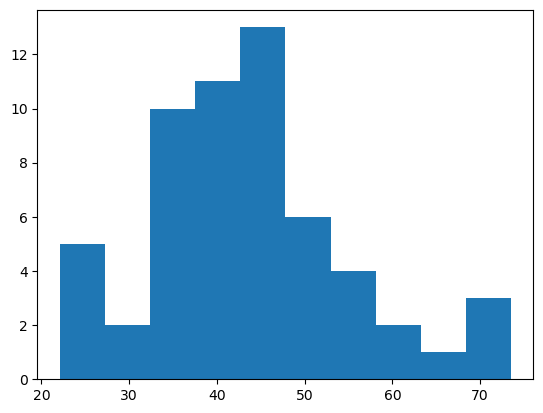

In [23]:
plt.hist(vmaxs_ana)

Text(0.05, 0.95, 'RMSE = 23.25 km\nMAE = 17.38 km')

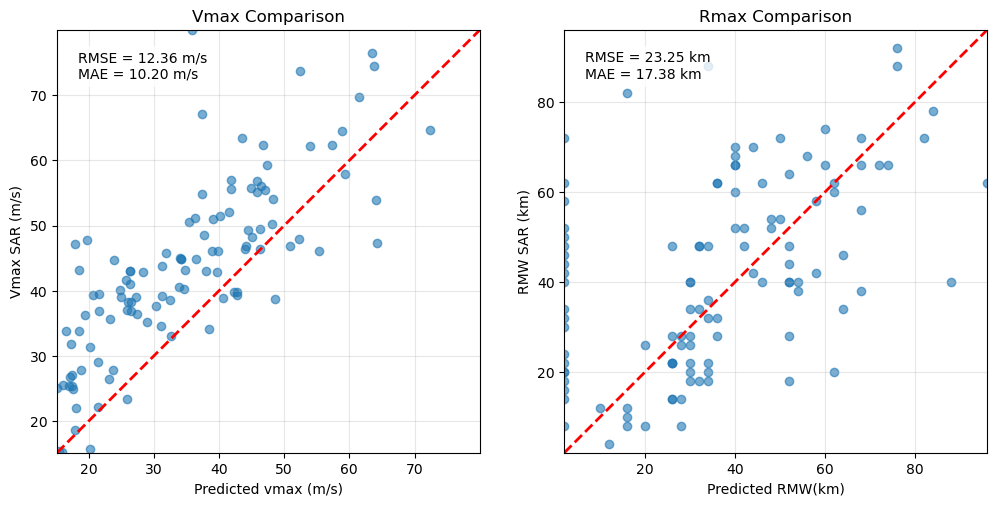

In [261]:
import numpy as np
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,2,figsize=(12,6))
# arrays -> numpy
vmax_pred = np.asarray(vmaxs_sar)[mask]
vmax_true = np.asarray(predicted_vmaxs)[mask]

# retirer NaN éventuels
valid = np.isfinite(vmax_pred) & np.isfinite(vmax_true)
vmax_pred = vmax_pred[valid]
vmax_true = vmax_true[valid]

# métriques
rmse = np.sqrt(np.mean((vmax_pred - vmax_true) ** 2))
mae = np.mean(np.abs(vmax_pred - vmax_true))

# limites communes
vmin = min(vmax_pred.min(), vmax_true.min())
vmax = max(vmax_pred.max(), vmax_true.max())


axs[0].scatter(vmax_true, vmax_pred, alpha=0.6)

# ligne parfaite
axs[0].plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2)

axs[0].set_xlabel("Predicted vmax (m/s)")
axs[0].set_ylabel("Vmax SAR (m/s)")
axs[0].set_title("Vmax Comparison")
axs[0].set_aspect('equal', adjustable='box')

axs[0].set_xlim(vmin, vmax)
axs[0].set_ylim(vmin, vmax)
axs[0].grid(True, alpha=0.3)

# texte métriques
axs[0].text(
    0.05, 0.95,
    f"RMSE = {rmse:.2f} m/s\nMAE = {mae:.2f} m/s",
    transform=axs[0].transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)




# arrays -> numpy
vmax_pred = np.asarray(rmaxs_sar)[mask]
vmax_true = np.asarray(predicted_rmaxs)[mask]

# retirer NaN éventuels
valid = np.isfinite(vmax_pred) & np.isfinite(vmax_true)
vmax_pred = vmax_pred[valid]
vmax_true = vmax_true[valid]

# métriques
rmse = np.sqrt(np.mean((vmax_pred - vmax_true) ** 2))
mae = np.mean(np.abs(vmax_pred - vmax_true))

# limites communes
vmin = min(vmax_pred.min(), vmax_true.min())
vmax = max(vmax_pred.max(), vmax_true.max())


plt.scatter(vmax_true, vmax_pred, alpha=0.6)

# ligne parfaite
axs[1].plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2)

axs[1].set_xlabel("Predicted RMW(km)")
axs[1].set_ylabel("RMW SAR (km)")
axs[1].set_title("Rmax Comparison")

axs[1].set_xlim(vmin, vmax)
axs[1].set_ylim(vmin, vmax)
axs[1].set_aspect('equal', adjustable='box')
axs[1].grid(True, alpha=0.3)

# texte métriques
axs[1].text(
    0.05, 0.95,
    f"RMSE = {rmse:.2f} km\nMAE = {mae:.2f} km",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)





Text(0.05, 0.95, 'RMSE = 14.02 km\nMAE = 10.45 km')

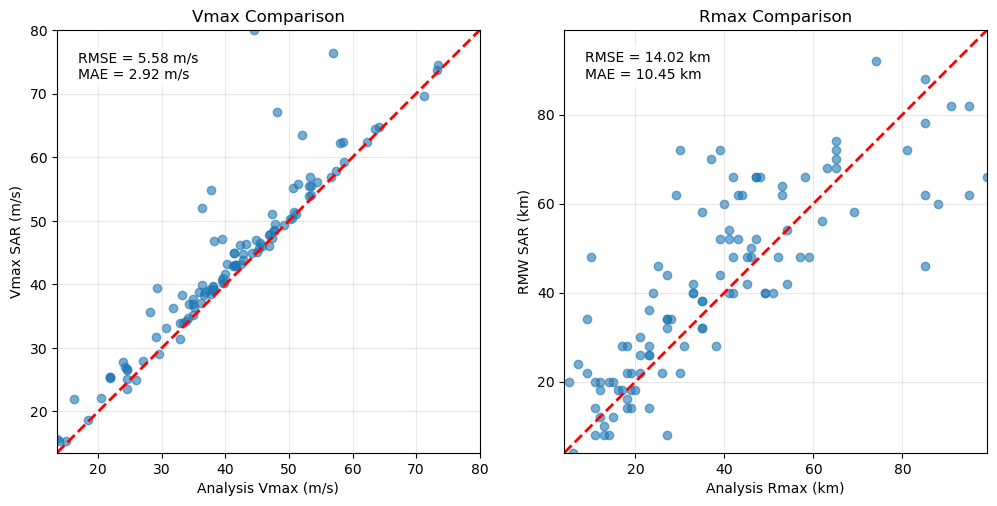

In [228]:
import numpy as np
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,2,figsize=(12,6))
# arrays -> numpy
vmax_pred = np.asarray(vmaxs_sar)[mask]
vmax_true = np.asarray(analysis_vmaxs)[mask]

# retirer NaN éventuels
valid = np.isfinite(vmax_pred) & np.isfinite(vmax_true)
vmax_pred = vmax_pred[valid]
vmax_true = vmax_true[valid]

# métriques
rmse = np.sqrt(np.mean((vmax_pred - vmax_true) ** 2))
mae = np.mean(np.abs(vmax_pred - vmax_true))

# limites communes
vmin = min(vmax_pred.min(), vmax_true.min())
vmax = max(vmax_pred.max(), vmax_true.max())


axs[0].scatter(vmax_true, vmax_pred, alpha=0.6)

# ligne parfaite
axs[0].plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2)

axs[0].set_xlabel("Analysis Vmax (m/s)")
axs[0].set_ylabel("Vmax SAR (m/s)")
axs[0].set_title("Vmax Comparison")
axs[0].set_aspect('equal', adjustable='box')

axs[0].set_xlim(vmin, vmax)
axs[0].set_ylim(vmin, vmax)
axs[0].grid(True, alpha=0.3)

# texte métriques
axs[0].text(
    0.05, 0.95,
    f"RMSE = {rmse:.2f} m/s\nMAE = {mae:.2f} m/s",
    transform=axs[0].transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)




# arrays -> numpy
vmax_pred = np.asarray(rmaxs_sar)[mask]
vmax_true = np.asarray(analysis_rmaxs)[mask]

# retirer NaN éventuels
valid = np.isfinite(vmax_pred) & np.isfinite(vmax_true)
vmax_pred = vmax_pred[valid]
vmax_true = vmax_true[valid]

# métriques
rmse = np.sqrt(np.mean((vmax_pred - vmax_true) ** 2))
mae = np.mean(np.abs(vmax_pred - vmax_true))

# limites communes
vmin = min(vmax_pred.min(), vmax_true.min())
vmax = max(vmax_pred.max(), vmax_true.max())


plt.scatter(vmax_true, vmax_pred, alpha=0.6)

# ligne parfaite
axs[1].plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2)

axs[1].set_xlabel("Analysis Rmax (km)")
axs[1].set_ylabel("RMW SAR (km)")
axs[1].set_title("Rmax Comparison")

axs[1].set_xlim(vmin, vmax)
axs[1].set_ylim(vmin, vmax)
axs[1].set_aspect('equal', adjustable='box')
axs[1].grid(True, alpha=0.3)

# texte métriques
axs[1].text(
    0.05, 0.95,
    f"RMSE = {rmse:.2f} km\nMAE = {mae:.2f} km",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)





## Anggrek evaluation

In [262]:
with open(os.path.join(folder_result,"stats_normalisation/Anggrek_data_normalised/data.pkl"),"rb") as f :
    anggrek_data = pkl.load(f)
anggrek_data.keys()

dict_keys(['IR_anggrek', 'infos_anggrek'])

In [263]:
ir_ang = anggrek_data["IR_anggrek"].squeeze()
infos_ang = anggrek_data["infos_anggrek"]
vmaxs_ang  = [d["vmax"] for d in infos_ang]

In [264]:
ir_ang_norm = ir_ang
def denorm(t, mean, std):
            return t * (std + 1e-10) + mean
ir_ang_denorm = denorm(ir_ang,mean_x[0],std_x[0])
ir_ang_norm.shape

(153, 128, 128)

In [265]:
pred_ang = []
for ir in ir_ang_norm:
    with torch.no_grad():
        ir = (
        torch.from_numpy(ir)
        .float()
        .unsqueeze(0)   # batch
        .unsqueeze(0)   # channel
        .to(device)
        )
        out = model(ir, timestep=0)
        aam_pred = out.sample if hasattr(out, "sample") else out
        pred_ang.append(aam_pred.cpu())

In [266]:
pred_ang = np.array(pred_ang).squeeze()
pred_ang.shape

(153, 128, 128)

In [267]:
sar_ang = []
for i,pred in enumerate(pred_ang):
    aam_pred_denorm = annular_denormalization(pred.reshape((1,128,128)),stats={"mean":mean_sar,"std":std_sar})
    sar_pred_ang = moment_to_sar(aam_pred_denorm)
    sar_ang.append(sar_pred_ang)
sar_ang = np.array(sar_ang).squeeze()
sar_ang.shape

(153, 128, 128)

In [268]:
ind = -1

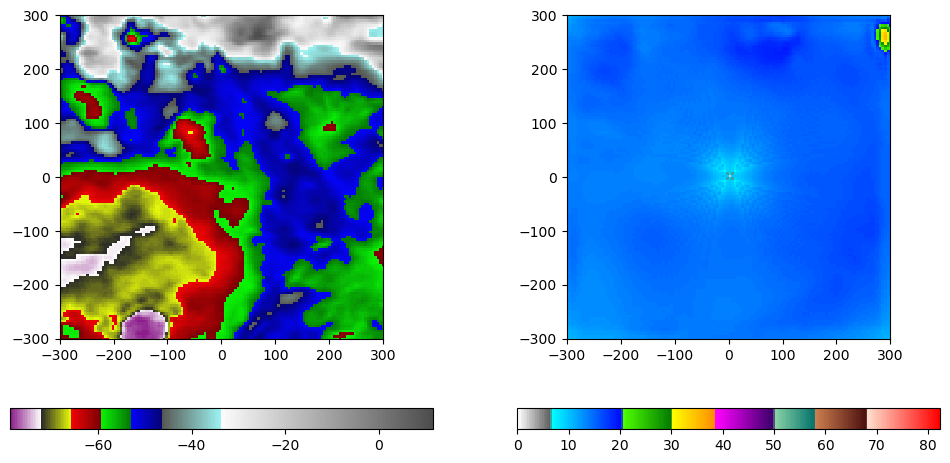

In [269]:
fig,axs = plt.subplots(1,2,figsize=(12,6))
ind +=1
plot_ir(ir_ang_denorm[ind],fig=fig, ax=axs[0])
plot_sar(sar_ang[ind],fig=fig, ax=axs[1])

In [272]:
vmax_pred_ang = []
for sar in sar_ang:
    vmax, rmax = compute_vmax1d_rmax1d(sar,71)
    vmax_pred_ang.append(vmax)
vmax_pred_ang = np.array(vmax_pred_ang)

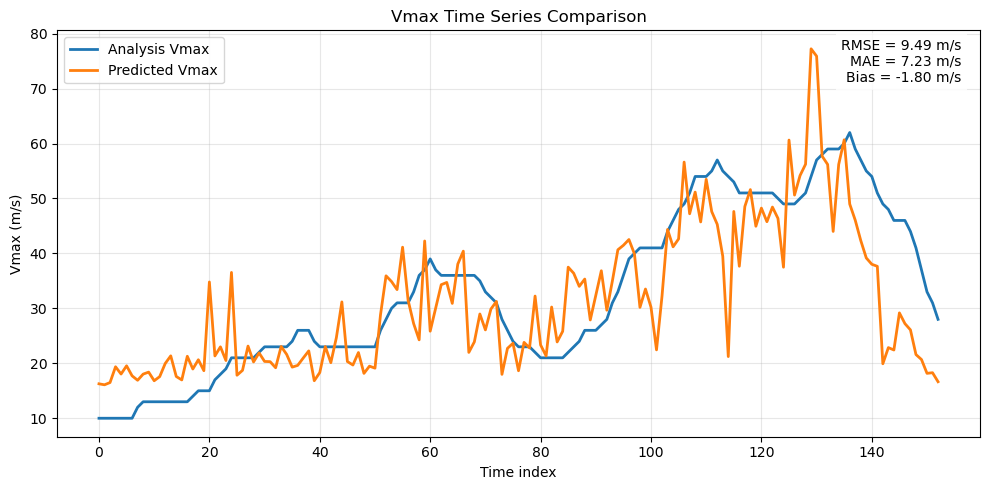

In [273]:
import numpy as np
import matplotlib.pyplot as plt

# tableaux numpy
true_vmax = np.array(vmaxs_ang)
pred_vmax = np.array(vmax_pred_ang)

# garder seulement valeurs valides

true_vmax = true_vmax
pred_vmax = pred_vmax

# métriques
err = pred_vmax - true_vmax
rmse = np.sqrt(np.mean(err**2))
mae = np.mean(np.abs(err))
bias = np.mean(err)

# plot
plt.figure(figsize=(10,5))

plt.plot(true_vmax, label="Analysis Vmax", linewidth=2)
plt.plot(pred_vmax, label="Predicted Vmax", linewidth=2)

plt.xlabel("Time index")
plt.ylabel("Vmax (m/s)")
plt.title("Vmax Time Series Comparison")
plt.grid(alpha=0.3)
plt.legend()

# boîte de métriques
text = (
    f"RMSE = {rmse:.2f} m/s\n"
    f"MAE = {mae:.2f} m/s\n"
    f"Bias = {bias:.2f} m/s"
)

plt.text(
    0.98, 0.98, text,
    transform=plt.gca().transAxes,
    ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.tight_layout()
plt.show()
